# 🧩 Notebook 2 — Benchmark ANN sobre representaciones Dialog2Flow 2.0

En esta notebook trabajamos con los embeddings generados en las notebooks anteriores.

El objetivo es evaluar métodos de **Approximate Nearest Neighbor Search** (ANN) usando **FAISS** sobre una colección ampliada de diálogos orientados a tareas.

La notebook permite comparar embeddings semánticos generales (`all-MiniLM-L6-v2`, `all-mpnet-base-v2`) con embeddings específicos para flujos conversacionales (`dialog2flow-joint-bert-base`).

La evaluación se organiza como un benchmark:

1. se cargan embeddings precomputados;
2. se separan vectores **indexados** y vectores de **consulta**;
3. se construye un índice exacto `FlatL2` como *ground truth*;
4. se evalúan índices aproximados variando parámetros;
5. se reportan `Recall@1`, `Recall@10`, `Recall@100`, QPS, tiempo de construcción y memoria aproximada.


## 1️⃣ Instalación de dependencias

Instalamos las librerías necesarias para descargar los archivos desde Google Drive, cargar los datos y ejecutar FAISS.

In [1]:
!pip install -q gdown faiss-cpu scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 47.1 MB/s eta 0:00:00


## 2️⃣ Parámetros del experimento

`EMBEDDING_EXPERIMENTO` permite seleccionar el archivo de embeddings a evaluar.

Opciones disponibles:

- `all-MiniLM-L6-v2`: embeddings semánticos generales de 384 dimensiones.
- `all-mpnet-base-v2`: embeddings semánticos generales de 768 dimensiones.
- `dialog2flow-joint-bert-base`: embeddings específicos para flujos conversacionales TOD de 768 dimensiones.

`N_QUERIES` define cuántos vectores se separan como consultas. El resto de los vectores se usa como base indexada.

La separación evita que una consulta recupere su propio vector como vecino más cercano.


In [2]:
# EMBEDDING_EXPERIMENTO = "all-MiniLM-L6-v2"
# EMBEDDING_EXPERIMENTO = "all-mpnet-base-v2"
EMBEDDING_EXPERIMENTO = "dialog2flow-joint-bert-base"

N_QUERIES = 10000
RANDOM_STATE = 42
K_MAX = 100

NORMALIZAR_VECTORES = True
N_REPETICIONES_BUSQUEDA = 3

print("Modelo seleccionado:", EMBEDDING_EXPERIMENTO)
print("Cantidad de queries:", N_QUERIES)
print("Repeticiones por búsqueda:", N_REPETICIONES_BUSQUEDA)


Modelo seleccionado: dialog2flow-joint-bert-base
Cantidad de queries: 10000
Repeticiones por búsqueda: 3


## 3️⃣ Archivos de entrada

Los archivos utilizados fueron generados previamente:

- `ids.npy`: identificadores asociados a cada embedding.
- `embeddings_minilm.npy`: embeddings generados con `all-MiniLM-L6-v2`.
- `embeddings_mpnet.npy`: embeddings generados con `all-mpnet-base-v2`.
- `embeddings_dialog2flow.npy`: embeddings generados con `sergioburdisso/dialog2flow-joint-bert-base`.

El dataframe `dialogs-2.0.pkl` no se carga al inicio para reducir el uso de memoria. Solo se descarga al final si se desea realizar una inspección cualitativa de vecinos.

A continuación se definen los identificadores de Google Drive.


In [3]:
# Ids de Google Drive
id_ids = "1hWC7nLvSboFHyykjr7VFAEmcvz8re1cY"

id_embeddings_mpnet = "1ndtChhGE3U5bkJ59NvuXhbX5Bgr7uOGe"
id_embeddings_minilm = "1imF_9lIGgGRJ7KQm-KhRPyinDUqPI_fW"
id_embeddings_dialog2flow = "1Pxf6oho0HYwv3B8VObZ_R6asShyK1WFW"

id_dataset = "1kRbmvg3NB96pWMUl866GZRrT6Zq9vxcb"


## 4️⃣ Descarga de datos

Según el modelo seleccionado, se descarga el archivo de embeddings correspondiente.

También se descargan los identificadores `ids.npy`. El dataframe `dialogs-2.0.pkl` se descarga recién al final, solo si se desea realizar una inspección cualitativa de vecinos. Esto reduce el uso de memoria durante el benchmark.

Si el archivo ya existe en el entorno de Colab, no se vuelve a descargar.

Nota: los embeddings de `dialog2flow-joint-bert-base` se calculan a nivel de turno. No requieren que los turnos estén ordenados para ser generados, pero sí deben permanecer alineados fila a fila con `ids.npy` y con el dataframe original.


In [4]:
import os
import gdown

def descargar_desde_drive(file_id, output):
    if os.path.exists(output):
        print(f"{output} ya existe. No se descarga nuevamente.")
    else:
        gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

if EMBEDDING_EXPERIMENTO == "all-MiniLM-L6-v2":
    id_embeddings = id_embeddings_minilm
    archivo_embeddings = "embeddings_minilm.npy"

elif EMBEDDING_EXPERIMENTO == "all-mpnet-base-v2":
    id_embeddings = id_embeddings_mpnet
    archivo_embeddings = "embeddings_mpnet.npy"

elif EMBEDDING_EXPERIMENTO == "dialog2flow-joint-bert-base":
    id_embeddings = id_embeddings_dialog2flow
    archivo_embeddings = "embeddings_dialog2flow.npy"

else:
    raise ValueError("Modelo de embeddings no reconocido.")

descargar_desde_drive(id_embeddings, archivo_embeddings)
descargar_desde_drive(id_ids, "ids.npy")


Downloading...
From (original): https://drive.google.com/uc?id=1Pxf6oho0HYwv3B8VObZ_R6asShyK1WFW
From (redirected): https://drive.google.com/uc?id=1Pxf6oho0HYwv3B8VObZ_R6asShyK1WFW&confirm=t&uuid=cc632d12-0d1e-4fb1-89b1-8be32d6e920f
To: /content/embeddings_dialog2flow.npy
100%|██████████| 3.07G/3.07G [00:42<00:00, 73.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1hWC7nLvSboFHyykjr7VFAEmcvz8re1cY
To: /content/ids.npy
100%|██████████| 8.00M/8.00M [00:00<00:00, 60.8MB/s]


## 5️⃣ Carga de embeddings

Cargamos los embeddings y sus identificadores.

Usamos `mmap_mode="r"` para leer el archivo `.npy` sin cargarlo completamente de entrada en memoria. Luego, al separar los conjuntos, se generan los arrays necesarios para FAISS.


In [5]:
import numpy as np
import pandas as pd

embeddings = np.load(archivo_embeddings, mmap_mode="r")
ids = np.load("ids.npy")

print("Embeddings:", embeddings.shape, embeddings.dtype)
print("Ids:", ids.shape)


Embeddings: (1000023, 768) float32
Ids: (1000023,)


## 6️⃣ Validación de consistencia

Verificamos que la cantidad de embeddings coincida con la cantidad de identificadores.


In [6]:
assert embeddings.shape[0] == ids.shape[0], "La cantidad de embeddings no coincide con ids."

print("Validación correcta.")


Validación correcta.


## 7️⃣ Separación entre vectores indexados y consultas

Separamos los vectores en dos subconjuntos:

- `index_vectors`: vectores que se incorporan al índice FAISS.
- `query_vectors`: vectores que se usan como consultas.

La lógica es similar a un `train_test_split`, pero aplicada a recuperación: unos vectores quedan como **buscados** y otros como **buscadores**.

In [7]:
from sklearn.model_selection import train_test_split
import gc

indices = np.arange(embeddings.shape[0])

index_idx, query_idx = train_test_split(
    indices,
    test_size=N_QUERIES,
    random_state=RANDOM_STATE,
    shuffle=True
)

index_vectors = np.asarray(embeddings[index_idx], dtype="float32")
query_vectors = np.asarray(embeddings[query_idx], dtype="float32")

index_ids = ids[index_idx]
query_ids = ids[query_idx]

# Ya no necesitamos el memmap, los ids completos ni los índices auxiliares.
# Liberarlos ayuda a reducir presión de RAM antes de construir índices FAISS.
del embeddings
del ids
del indices
del index_idx
del query_idx
gc.collect()

print("Vectores indexados:", index_vectors.shape)
print("Vectores de consulta:", query_vectors.shape)
print("Ids indexados:", index_ids.shape)
print("Ids de consulta:", query_ids.shape)


Vectores indexados: (990023, 768)
Vectores de consulta: (10000, 768)
Ids indexados: (990023,)
Ids de consulta: (10000,)


## 8️⃣ Normalización de vectores

Los embeddings semánticos suelen compararse mediante similitud coseno.

Para usar FAISS con distancia L2 y conservar un comportamiento equivalente al ordenamiento por similitud coseno, normalizamos los vectores a norma unitaria.

In [8]:
import faiss

if NORMALIZAR_VECTORES:
    faiss.normalize_L2(index_vectors)
    faiss.normalize_L2(query_vectors)
    print("Vectores normalizados con norma L2.")
else:
    print("No se aplicó normalización.")

Vectores normalizados con norma L2.


## 9️⃣ Funciones auxiliares para benchmark

Definimos funciones para calcular `Recall@k`, medir tiempos, estimar memoria del índice y registrar resultados en una tabla.

Para estabilizar la medición de QPS, cada búsqueda realiza un pequeño **warm-up** y luego repite la medición `N_REPETICIONES_BUSQUEDA` veces, conservando la mediana de los tiempos observados.


In [9]:
import time
import platform
import ast

results = []
MB = 1024 ** 2

def recall_at_k(indices_exactos, indices_aproximados, k):
    recalls = []

    for exactos, aproximados in zip(indices_exactos[:, :k], indices_aproximados[:, :k]):
        exactos = set(exactos)
        aproximados = set(aproximados)
        recalls.append(len(exactos.intersection(aproximados)) / k)

    return float(np.mean(recalls))


def estimate_flat_memory_mb(n, d):
    return (n * d * 4) / MB


def estimate_ivf_memory_mb(n, d, nlist):
    # Vectores float32 + ids int64 + centroides del coarse quantizer.
    return ((n * d * 4) + (n * 8) + (nlist * d * 4)) / MB


def estimate_hnsw_memory_mb(n, d, M):
    # Estimación aproximada: vectores float32 + enlaces del grafo.
    # El factor 8 contempla overhead simplificado por vecino.
    return ((n * d * 4) + (n * M * 8)) / MB


def estimate_ivfpq_memory_mb(n, d, nlist, m, nbits):
    # Códigos comprimidos + ids + centroides + codebooks PQ.
    code_size_bytes = m * nbits / 8
    coarse_centroids = nlist * d * 4
    pq_codebooks = m * (2 ** nbits) * (d // m) * 4
    return ((n * code_size_bytes) + (n * 8) + coarse_centroids + pq_codebooks) / MB


def log_result(index_type, params, build_time_s, search_time_s, indices_recuperados, memory_mb=None):
    results.append({
        "embedding_model": EMBEDDING_EXPERIMENTO,
        "index_type": index_type,
        "params": params,
        "nlist": params.get("nlist"),
        "nprobe": params.get("nprobe"),
        "M": params.get("M"),
        "efConstruction": params.get("efConstruction"),
        "efSearch": params.get("efSearch"),
        "m": params.get("m"),
        "nbits": params.get("nbits"),
        "num_index_vectors": index_vectors.shape[0],
        "num_query_vectors": query_vectors.shape[0],
        "dimension": index_vectors.shape[1],
        "build_time_s": build_time_s,
        "search_time_s": search_time_s,
        "qps": query_vectors.shape[0] / search_time_s,
        "recall@1": recall_at_k(I_exact, indices_recuperados, 1),
        "recall@10": recall_at_k(I_exact, indices_recuperados, 10),
        "recall@100": recall_at_k(I_exact, indices_recuperados, 100),
        "memory_mb": memory_mb,
    })


def buscar_con_tiempo(index, queries, k):
    # Warm-up para evitar medir inicializaciones internas o efectos de caché inicial.
    index.search(queries[:min(100, len(queries))], k)

    tiempos = []
    D_final, I_final = None, None

    for _ in range(N_REPETICIONES_BUSQUEDA):
        t0 = time.time()
        D, I = index.search(queries, k)
        t1 = time.time()

        tiempos.append(t1 - t0)
        D_final, I_final = D, I

    search_time = float(np.median(tiempos))
    return D_final, I_final, search_time

print("Python:", platform.python_version())
print("FAISS:", faiss.__version__)
print("Numpy:", np.__version__)
print("Pandas:", pd.__version__)


Python: 3.12.13
FAISS: 1.14.2
Numpy: 2.0.2
Pandas: 2.2.2


## 🔟 Ground truth con búsqueda exacta `FlatL2`

Construimos un índice exacto con `IndexFlatL2` sobre `index_vectors`.

Este índice se usa como **ground truth**: los vecinos recuperados por IVF, HNSW e IVFPQ se comparan contra los vecinos exactos devueltos por FlatL2.

In [10]:
d = index_vectors.shape[1]
n_index = index_vectors.shape[0]

t0 = time.time()
index_flat = faiss.IndexFlatL2(d)
index_flat.add(index_vectors)
t1 = time.time()

build_time_flat = t1 - t0
memory_flat = estimate_flat_memory_mb(n_index, d)

D_exact, I_exact, search_time_flat = buscar_con_tiempo(index_flat, query_vectors, K_MAX)

results.append({
    "embedding_model": EMBEDDING_EXPERIMENTO,
    "index_type": "FlatL2",
    "params": {},
    "nlist": None,
    "nprobe": None,
    "M": None,
    "efConstruction": None,
    "efSearch": None,
    "m": None,
    "nbits": None,
    "num_index_vectors": index_vectors.shape[0],
    "num_query_vectors": query_vectors.shape[0],
    "dimension": index_vectors.shape[1],
    "build_time_s": build_time_flat,
    "search_time_s": search_time_flat,
    "qps": query_vectors.shape[0] / search_time_flat,
    "recall@1": 1.0,
    "recall@10": 1.0,
    "recall@100": 1.0,
    "memory_mb": memory_flat,
})

print("FlatL2 construido.")
print("Tiempo de construcción:", build_time_flat)
print("Tiempo de búsqueda:", search_time_flat)
print("QPS:", query_vectors.shape[0] / search_time_flat)
print("Memoria aproximada MB:", memory_flat)

# Ya tenemos I_exact como ground truth. El índice exacto y las distancias no se vuelven a usar.
del index_flat
del D_exact
gc.collect()


FlatL2 construido.
Tiempo de construcción: 3.598189353942871
Tiempo de búsqueda: 297.6841278076172
QPS: 33.5926543133084
Memoria aproximada MB: 2900.4580078125


0

## 1️⃣1️⃣ Benchmark IVF

Evaluamos `IndexIVFFlat`, un índice basado en partición del espacio vectorial.

El parámetro principal es `nprobe`, que indica cuántas listas invertidas se exploran durante la búsqueda.

- valores bajos de `nprobe`: más velocidad, menor recall;
- valores altos de `nprobe`: mayor recall, menor velocidad.

IVF requiere una etapa de entrenamiento para aprender los centroides que dividen el espacio en `nlist` regiones. Para eso usamos una muestra de `index_vectors`, pero luego agregamos al índice todos los vectores indexados.


In [11]:
nlist = 4096
nprobe_values = [1, 2, 4, 8, 16, 32, 64]
IVF_TRAIN_SIZE = 100000

np.random.seed(RANDOM_STATE)
train_size = min(IVF_TRAIN_SIZE, index_vectors.shape[0])
train_idx = np.random.choice(index_vectors.shape[0], size=train_size, replace=False)
train_vectors = index_vectors[train_idx]

quantizer = faiss.IndexFlatL2(d)
index_ivf = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_L2)

t0 = time.time()
index_ivf.train(train_vectors)
index_ivf.add(index_vectors)
t1 = time.time()

build_time_ivf = t1 - t0
memory_ivf = estimate_ivf_memory_mb(n_index, d, nlist)

for nprobe in nprobe_values:
    index_ivf.nprobe = nprobe
    D_ivf, I_ivf, search_time_ivf = buscar_con_tiempo(index_ivf, query_vectors, K_MAX)

    log_result(
        index_type="IVF",
        params={"nlist": nlist, "nprobe": nprobe},
        build_time_s=build_time_ivf,
        search_time_s=search_time_ivf,
        indices_recuperados=I_ivf,
        memory_mb=memory_ivf,
    )

    print("IVF", {"nlist": nlist, "nprobe": nprobe}, "QPS:", query_vectors.shape[0] / search_time_ivf)

# Liberamos el índice IVF y objetos temporales antes de construir HNSW.
del index_ivf
del quantizer
del train_vectors
del D_ivf
del I_ivf
gc.collect()


IVF {'nlist': 4096, 'nprobe': 1} QPS: 4405.407608261819
IVF {'nlist': 4096, 'nprobe': 2} QPS: 3312.0309530053396
IVF {'nlist': 4096, 'nprobe': 4} QPS: 2011.5565475232718
IVF {'nlist': 4096, 'nprobe': 8} QPS: 1204.048905185782
IVF {'nlist': 4096, 'nprobe': 16} QPS: 700.0679236987946
IVF {'nlist': 4096, 'nprobe': 32} QPS: 383.3163637812579
IVF {'nlist': 4096, 'nprobe': 64} QPS: 203.49301049746


0

## 1️⃣2️⃣ Benchmark HNSW

Evaluamos `IndexHNSWFlat`, un índice basado en grafos navegables.

El parámetro `M` controla la conectividad del grafo y `efSearch` controla la amplitud de exploración durante la búsqueda.

En este bloque fijamos `M` y variamos `efSearch`.

In [12]:
M = 32
ef_construction = 200
ef_search_values = [8, 16, 32, 64, 128, 256]

index_hnsw = faiss.IndexHNSWFlat(d, M)
index_hnsw.hnsw.efConstruction = ef_construction

t0 = time.time()
index_hnsw.add(index_vectors)
t1 = time.time()

build_time_hnsw = t1 - t0
memory_hnsw = estimate_hnsw_memory_mb(n_index, d, M)

for ef_search in ef_search_values:
    index_hnsw.hnsw.efSearch = ef_search
    D_hnsw, I_hnsw, search_time_hnsw = buscar_con_tiempo(index_hnsw, query_vectors, K_MAX)

    log_result(
        index_type="HNSW",
        params={"M": M, "efConstruction": ef_construction, "efSearch": ef_search},
        build_time_s=build_time_hnsw,
        search_time_s=search_time_hnsw,
        indices_recuperados=I_hnsw,
        memory_mb=memory_hnsw,
    )

    print("HNSW", {"M": M, "efSearch": ef_search}, "QPS:", query_vectors.shape[0] / search_time_hnsw)

# Liberamos el índice HNSW antes de construir IVFPQ.
del index_hnsw
del D_hnsw
del I_hnsw
gc.collect()


HNSW {'M': 32, 'efSearch': 8} QPS: 8073.491551262667
HNSW {'M': 32, 'efSearch': 16} QPS: 6401.153528185545
HNSW {'M': 32, 'efSearch': 32} QPS: 3979.825625296876
HNSW {'M': 32, 'efSearch': 64} QPS: 2939.7581106281023
HNSW {'M': 32, 'efSearch': 128} QPS: 1998.1531999838217
HNSW {'M': 32, 'efSearch': 256} QPS: 1041.4852817931


0

## 1️⃣3️⃣ Benchmark IVFPQ

Evaluamos `IndexIVFPQ`, que combina partición del espacio vectorial con Product Quantization.

Este índice suele reducir mucho la memoria necesaria, aunque puede perder recall respecto de IVF o HNSW.

En este bloque fijamos `nlist`, `m` y `nbits`, y variamos `nprobe`.

In [13]:
nlist_pq = 4096
m = 32
nbits = 8
nprobe_values_pq = [1, 2, 4, 8, 16, 32, 64]

assert d % m == 0, "La dimensión de los embeddings debe ser divisible por m."

# IVFPQ también requiere entrenamiento.
# Reutilizamos los mismos índices de entrenamiento seleccionados para IVF,
# pero reconstruimos la muestra para no mantener train_vectors en RAM entre bloques.
train_vectors_pq = index_vectors[train_idx]

quantizer_pq = faiss.IndexFlatL2(d)
index_ivfpq = faiss.IndexIVFPQ(quantizer_pq, d, nlist_pq, m, nbits)

t0 = time.time()
index_ivfpq.train(train_vectors_pq)
index_ivfpq.add(index_vectors)
t1 = time.time()

build_time_ivfpq = t1 - t0
memory_ivfpq = estimate_ivfpq_memory_mb(n_index, d, nlist_pq, m, nbits)

for nprobe in nprobe_values_pq:
    index_ivfpq.nprobe = nprobe
    D_ivfpq, I_ivfpq, search_time_ivfpq = buscar_con_tiempo(index_ivfpq, query_vectors, K_MAX)

    log_result(
        index_type="IVFPQ",
        params={"nlist": nlist_pq, "m": m, "nbits": nbits, "nprobe": nprobe},
        build_time_s=build_time_ivfpq,
        search_time_s=search_time_ivfpq,
        indices_recuperados=I_ivfpq,
        memory_mb=memory_ivfpq,
    )

    print("IVFPQ", {"nprobe": nprobe}, "QPS:", query_vectors.shape[0] / search_time_ivfpq)

# Liberamos el índice IVFPQ y objetos temporales.
del index_ivfpq
del quantizer_pq
del train_vectors_pq
del train_idx
del D_ivfpq
del I_ivfpq
gc.collect()


IVFPQ {'nprobe': 1} QPS: 4225.616664608079
IVFPQ {'nprobe': 2} QPS: 4132.634757826337
IVFPQ {'nprobe': 4} QPS: 2909.384916397316
IVFPQ {'nprobe': 8} QPS: 2542.1959392787717
IVFPQ {'nprobe': 16} QPS: 2020.0153893403412
IVFPQ {'nprobe': 32} QPS: 1351.9360519353363
IVFPQ {'nprobe': 64} QPS: 865.0360468465772


0

## 1️⃣4️⃣ Tabla de resultados

Convertimos los resultados registrados a un dataframe para analizarlos y exportarlos.

In [14]:
df_results = pd.DataFrame(results)
df_results

,embedding_model,index_type,params,nlist,nprobe,M,efConstruction,efSearch,m,nbits,num_index_vectors,num_query_vectors,dimension,build_time_s,search_time_s,qps,recall@1,recall@10,recall@100,memory_mb
0,dialog2flow-joint-bert-base,FlatL2,{},NaN,NaN,NaN,NaN,NaN,NaN,NaN,990023,10000,768,3.598189,297.684128,33.592654,1.0000,1.00000,1.000000,2900.458008
1,dialog2flow-joint-bert-base,IVF,"{'nlist': 4096, 'nprobe': 1}",4096.0,1.0,NaN,NaN,NaN,NaN,NaN,990023,10000,768,237.400021,2.269938,4405.407608,0.6321,0.74516,0.684028,2920.011284
2,dialog2flow-joint-bert-base,IVF,"{'nlist': 4096, 'nprobe': 2}",4096.0,2.0,NaN,NaN,NaN,NaN,NaN,990023,10000,768,237.400021,3.019295,3312.030953,0.6646,0.82286,0.821643,2920.011284
3,dialog2flow-joint-bert-base,IVF,"{'nlist': 4096, 'nprobe': 4}",4096.0,4.0,NaN,NaN,NaN,NaN,NaN,990023,10000,768,237.400021,4.971275,2011.556548,0.6767,0.85911,0.899860,2920.011284
4,dialog2flow-joint-bert-base,IVF,"{'nlist': 4096, 'nprobe': 8}",4096.0,8.0,NaN,NaN,NaN,NaN,NaN,990023,10000,768,237.400021,8.305310,1204.048905,0.6812,0.87313,0.932556,2920.011284
5,dialog2flow-joint-bert-base,IVF,"{'nlist': 4096, 'nprobe': 16}",4096.0,16.0,NaN,NaN,NaN,NaN,NaN,990023,10000,768,237.400021,14.284328,700.067924,0.6834,0.87833,0.945999,2920.011284
6,dialog2flow-joint-bert-base,IVF,"{'nlist': 4096, 'nprobe': 32}",4096.0,32.0,NaN,NaN,NaN,NaN,NaN,990023,10000,768,237.400021,26.088111,383.316364,0.6841,0.88038,0.951131,2920.011284
7,dialog2flow-joint-bert-base,IVF,"{'nlist': 4096, 'nprobe': 64}",4096.0,64.0,NaN,NaN,NaN,NaN,NaN,990023,10000,768,237.400021,49.141737,203.493010,0.6846,0.88124,0.953399,2920.011284
8,dialog2flow-joint-bert-base,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 8}",NaN,NaN,32.0,200.0,8.0,NaN,NaN,990023,10000,768,993.008186,1.238621,8073.491551,0.6398,0.82254,0.475453,3142.162842
9,dialog2flow-joint-bert-base,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 16}",NaN,NaN,32.0,200.0,16.0,NaN,NaN,990023,10000,768,993.008186,1.562218,6401.153528,0.6550,0.84854,0.614408,3142.162842


## 1️⃣5️⃣ Curvas Recall vs QPS

Las curvas `Recall vs QPS` permiten observar el compromiso entre calidad de recuperación y velocidad.

Este es el gráfico central para comparar métodos ANN.

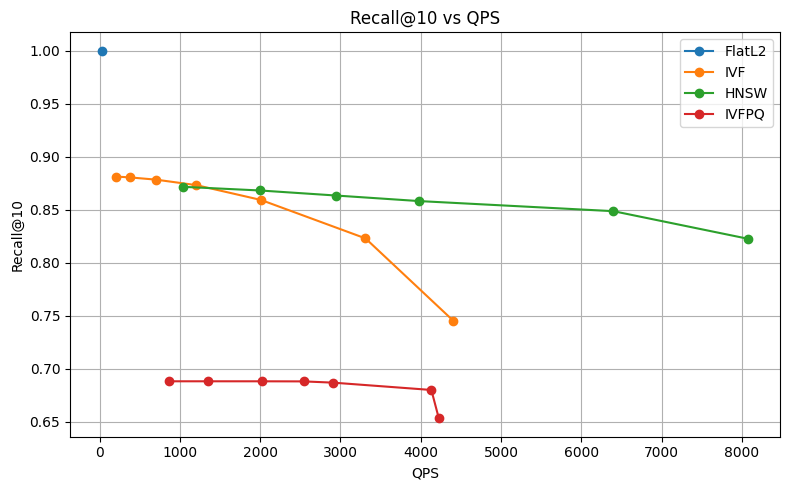

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for index_type in df_results["index_type"].unique():
    subset = df_results[df_results["index_type"] == index_type].sort_values("qps")
    plt.plot(subset["qps"], subset["recall@10"], marker="o", label=index_type)

plt.xlabel("QPS")
plt.ylabel("Recall@10")
plt.title("Recall@10 vs QPS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

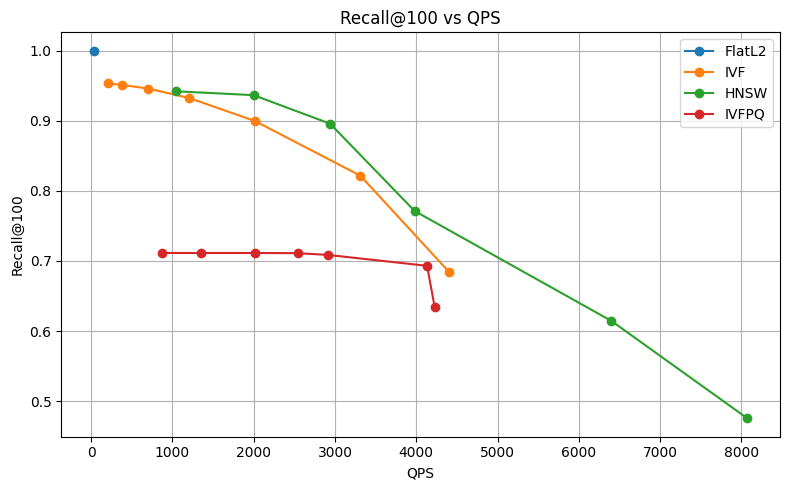

In [16]:
plt.figure(figsize=(8, 5))

for index_type in df_results["index_type"].unique():
    subset = df_results[df_results["index_type"] == index_type].sort_values("qps")
    plt.plot(subset["qps"], subset["recall@100"], marker="o", label=index_type)

plt.xlabel("QPS")
plt.ylabel("Recall@100")
plt.title("Recall@100 vs QPS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 1️⃣6️⃣ Diagnóstico por parámetro

Además de las curvas Recall vs QPS, se muestran tablas ordenadas por parámetro para interpretar el comportamiento interno de cada familia de índices. Esto ayuda a detectar mediciones anómalas, por ejemplo puntos donde un parámetro más restrictivo no resulta más rápido por ruido de ejecución.

In [17]:
# Diagnóstico por parámetro para interpretar las curvas Recall vs QPS.
# En IVF e IVFPQ, nprobe controla cuántas listas invertidas se exploran.
# En HNSW, efSearch controla la amplitud de búsqueda en el grafo.

print("IVF ordenado por nprobe")
display(
    df_results[df_results["index_type"] == "IVF"][
        ["nprobe", "qps", "recall@1", "recall@10", "recall@100"]
    ].sort_values("nprobe")
)

print("HNSW ordenado por efSearch")
display(
    df_results[df_results["index_type"] == "HNSW"][
        ["efSearch", "qps", "recall@1", "recall@10", "recall@100"]
    ].sort_values("efSearch")
)

print("IVFPQ ordenado por nprobe")
display(
    df_results[df_results["index_type"] == "IVFPQ"][
        ["nprobe", "qps", "recall@1", "recall@10", "recall@100"]
    ].sort_values("nprobe")
)


IVF ordenado por nprobe


,nprobe,qps,recall@1,recall@10,recall@100
1,1.0,4405.407608,0.6321,0.74516,0.684028
2,2.0,3312.030953,0.6646,0.82286,0.821643
3,4.0,2011.556548,0.6767,0.85911,0.899860
4,8.0,1204.048905,0.6812,0.87313,0.932556
5,16.0,700.067924,0.6834,0.87833,0.945999
6,32.0,383.316364,0.6841,0.88038,0.951131
7,64.0,203.493010,0.6846,0.88124,0.953399


HNSW ordenado por efSearch


,efSearch,qps,recall@1,recall@10,recall@100
8,8.0,8073.491551,0.6398,0.82254,0.475453
9,16.0,6401.153528,0.6550,0.84854,0.614408
10,32.0,3979.825625,0.6636,0.85808,0.771316
11,64.0,2939.758111,0.6687,0.86334,0.895859
12,128.0,1998.153200,0.6732,0.86808,0.936579
13,256.0,1041.485282,0.6760,0.87154,0.942141


IVFPQ ordenado por nprobe


,nprobe,qps,recall@1,recall@10,recall@100
14,1.0,4225.616665,0.7180,0.65301,0.634574
15,2.0,4132.634758,0.7275,0.67979,0.693090
16,4.0,2909.384916,0.7290,0.68670,0.708677
17,8.0,2542.195939,0.7296,0.68788,0.711129
18,16.0,2020.015389,0.7298,0.68797,0.711379
19,32.0,1351.936052,0.7298,0.68798,0.711405
20,64.0,865.036047,0.7298,0.68798,0.711406


## 1️⃣7️⃣ Memoria y tiempo de construcción

La memoria se reporta como una estimación aproximada, no como medición exacta de RAM. Se evita serializar los índices FAISS para no duplicar objetos grandes en memoria durante la ejecución en Colab.

In [18]:
cols = [
    "index_type", "nlist", "nprobe", "M", "efSearch", "m", "nbits",
    "build_time_s", "search_time_s", "qps",
    "recall@1", "recall@10", "recall@100", "memory_mb"
]

df_results[cols].sort_values(["index_type", "recall@10"], ascending=[True, False])


,index_type,nlist,nprobe,M,efSearch,m,nbits,build_time_s,search_time_s,qps,recall@1,recall@10,recall@100,memory_mb
0,FlatL2,NaN,NaN,NaN,NaN,NaN,NaN,3.598189,297.684128,33.592654,1.0000,1.00000,1.000000,2900.458008
13,HNSW,NaN,NaN,32.0,256.0,NaN,NaN,993.008186,9.601672,1041.485282,0.6760,0.87154,0.942141,3142.162842
12,HNSW,NaN,NaN,32.0,128.0,NaN,NaN,993.008186,5.004621,1998.153200,0.6732,0.86808,0.936579,3142.162842
11,HNSW,NaN,NaN,32.0,64.0,NaN,NaN,993.008186,3.401640,2939.758111,0.6687,0.86334,0.895859,3142.162842
10,HNSW,NaN,NaN,32.0,32.0,NaN,NaN,993.008186,2.512673,3979.825625,0.6636,0.85808,0.771316,3142.162842
9,HNSW,NaN,NaN,32.0,16.0,NaN,NaN,993.008186,1.562218,6401.153528,0.6550,0.84854,0.614408,3142.162842
8,HNSW,NaN,NaN,32.0,8.0,NaN,NaN,993.008186,1.238621,8073.491551,0.6398,0.82254,0.475453,3142.162842
7,IVF,4096.0,64.0,NaN,NaN,NaN,NaN,237.400021,49.141737,203.493010,0.6846,0.88124,0.953399,2920.011284
6,IVF,4096.0,32.0,NaN,NaN,NaN,NaN,237.400021,26.088111,383.316364,0.6841,0.88038,0.951131,2920.011284
5,IVF,4096.0,16.0,NaN,NaN,NaN,NaN,237.400021,14.284328,700.067924,0.6834,0.87833,0.945999,2920.011284


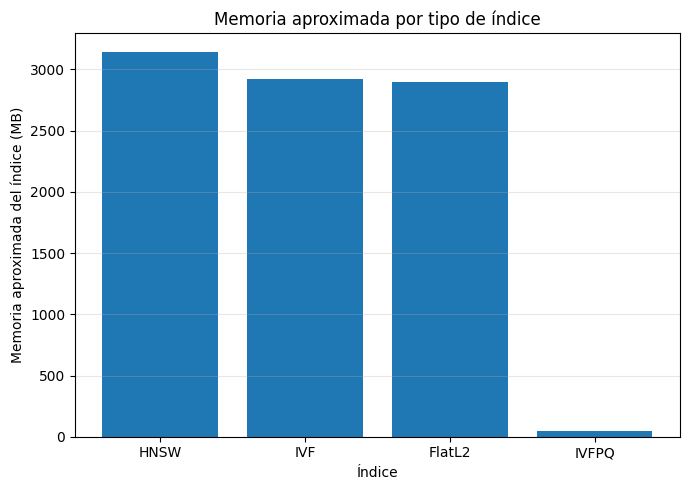

In [19]:
df_mem = (
    df_results
    .groupby("index_type", as_index=False)["memory_mb"]
    .max()
    .sort_values("memory_mb", ascending=False)
)

plt.figure(figsize=(7, 5))
plt.bar(df_mem["index_type"], df_mem["memory_mb"])

plt.xlabel("Índice")
plt.ylabel("Memoria aproximada del índice (MB)")
plt.title("Memoria aproximada por tipo de índice")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 1️⃣8️⃣ Exportación de resultados

In [20]:
from google.colab import drive
from datetime import datetime
from zoneinfo import ZoneInfo
import os

drive.mount("/content/drive")

carpeta_resultados = "/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados"
os.makedirs(carpeta_resultados, exist_ok=True)

fecha_hora_arg = datetime.now(ZoneInfo("America/Argentina/Buenos_Aires")).strftime("%Y%m%d_%H%M%S")

modelo = EMBEDDING_EXPERIMENTO.replace("/", "_").replace("-", "_")
archivo_resultados = f"resultados_ann_{modelo}_{fecha_hora_arg}_ARG.csv"

ruta_resultados = os.path.join(carpeta_resultados, archivo_resultados)

df_export = df_results.copy()
df_export["params"] = df_export["params"].astype(str)
df_export.to_csv(ruta_resultados, index=False)

print("Resultados guardados en:")
print(ruta_resultados)


Mounted at /content/drive
Resultados guardados en:
/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/resultados_ann_dialog2flow_joint_bert_base_20260528_092249_ARG.csv


## 1️⃣9️⃣ Inspección cualitativa opcional

In [21]:
descargar_desde_drive(id_dataset, "dialogs-2.0.pkl")
df = pd.read_pickle("dialogs-2.0.pkl")
print("Dataset cargado:", df.shape)


def obtener_fila_por_id(id_fila):
    try:
        return df.loc[id_fila]
    except Exception:
        return df.iloc[int(id_fila)]


def mostrar_vecinos(query_pos=0, indices_vecinos=I_exact, top=5):
    id_query = query_ids[query_pos]
    fila_query = obtener_fila_por_id(id_query)

    print("QUERY")
    print("id:", id_query)
    print("texto:", fila_query.get("utterance", fila_query.get("text", "")))
    print("-" * 80)

    for rank, idx_vecino in enumerate(indices_vecinos[query_pos, :top], start=1):
        id_vecino = index_ids[idx_vecino]
        fila_vecino = obtener_fila_por_id(id_vecino)

        print(f"Vecino {rank}")
        print("id:", id_vecino)
        print("texto:", fila_vecino.get("utterance", fila_vecino.get("text", "")))
        print("-" * 80)

mostrar_vecinos(query_pos=0, top=5)


Downloading...
From (original): https://drive.google.com/uc?id=1kRbmvg3NB96pWMUl866GZRrT6Zq9vxcb
From (redirected): https://drive.google.com/uc?id=1kRbmvg3NB96pWMUl866GZRrT6Zq9vxcb&confirm=t&uuid=a3905a1a-012a-4191-9e06-ffb893e327c0
To: /content/dialogs-2.0.pkl
100%|██████████| 156M/156M [00:00<00:00, 230MB/s]


Dataset cargado: (1000023, 11)
QUERY
id: 201446
texto: yes, please. i'd like a table for 1 on wednesday at 12:15 at the kohinoor.
--------------------------------------------------------------------------------
Vecino 1
id: 733785
texto: Yes, please. I'd like a table for 1 on wednesday at 12:15 at The Kohinoor.
--------------------------------------------------------------------------------
Vecino 2
id: 670919
texto: Yes, please. I'd like a table for 1 on wednesday at 12:15 at The Kohinoor.
--------------------------------------------------------------------------------
Vecino 3
id: 727164
texto: Yes, please book a table at Tang Chinese for 2 people at 17:30 on Tuesday.
--------------------------------------------------------------------------------
Vecino 4
id: 603904
texto: Yes, please book a table at Tang Chinese for 2 people at 17:30 on Tuesday.
--------------------------------------------------------------------------------
Vecino 5
id: 178239
texto: yes, please book a table at ta